# 05 `fmiss` Model Progression

This notebook is the counterexample chapter. It shows that the strategy that wins on `fpos` does not simply transfer to `fmiss`, and that the best `fmiss` path stayed more context-first and more conservative.

**Questions answered here**
- Which `fmiss` modeling path actually worked?
- Why did many `fpos`-inspired tricks fail to transfer?
- How broad were the winning `fmiss` gains across families and recordings?


## Model Architecture Rebuild Spec (Code-Accurate)

### Shared Mechanic (Global)

1. **Split protocol used by all models below**: `recording_disjoint_main` from `make_main_split(...)` with `paired_final_holdout_rows=100`, strict recording-disjoint holdout, and no holdout recording leakage into fine-tune or unlabeled pools.

### Per-Model Full Mechanism (Repeated Template; Split Not Repeated)

#### 1) Dummy paired mean (`fmiss_dummy`)
- Runner/family: `legacy_transfer` (`DummyRegressor(mean)`).
- Feature path: no stack frame; constant paired labeled mean baseline.
- Source transfer path: none.
- Unlabeled/pseudo path: none.
- Trust/manifold/anchor path: none.
- Final learner and fitting: constant predictor on holdout paired rows.
- SSL or representation learning: none.

#### 2) Hybrid stack residual (`fmiss_hybrid_residual`)
- Runner/family: `legacy_transfer` candidate `inductive|hybrid_stack|lightgbm_residual|unit_raw`.
- Feature path: `unit_raw` transfer features.
- Source transfer path: source model fit on hybrid target (`fmiss_extended`), then paired residual model fit on paired labeled rows.
- Unlabeled/pseudo path: none in this baseline transfer recipe.
- Trust/manifold/anchor path: none.
- Final learner and fitting: prediction is `source_pred + residual_pred` on holdout.
- SSL or representation learning: none.

#### 3) Best SSL neural (`fmiss_ssl`)
- Runner/family: `ssl_neural` (`run_ssl_with_config`).
- Feature path: unit tensor branches (`wf_bin_*`, `acg_*`, scalar) plus curated contextual columns.
- Source transfer path: supervised source-stage training on hybrid target (`fmiss_extended`) followed by paired fine-tune.
- Unlabeled/pseudo path: unlabeled paired pool (`ssl_pool`) is used for SSL pretraining objective.
- Trust/manifold/anchor path: none (not a stack pseudo pipeline).
- Final learner and fitting: neural contextual arm selected for the reported recipe (`ssl_fmiss_contextual`).
- SSL or representation learning: yes, masked denoising autoencoder pretraining.

#### 4) Best MMD neural (`fmiss_mmd`)
- Runner/family: `mmd_neural` (`run_mmd_with_config`).
- Feature path: unit-input neural model; paired/context LightGBM baselines are logged for reference.
- Source transfer path: supervised source-stage fit on hybrid source target.
- Unlabeled/pseudo path: unlabeled paired rows used in latent MMD alignment term; no pseudo labels.
- Trust/manifold/anchor path: none.
- Final learner and fitting: lambda sweep by grouped CV, then finetuned holdout variant (`neural_mmd_finetuned`).
- SSL or representation learning: no SSL pretraining.

#### 5) Paired-only context (`fmiss_paired_context` -> `contextual_paired_only_lightgbm`)
- Runner/family: `context_stack` compact stack variant.
- Feature path: filtered context columns only.
- Source transfer path: none (`source_pred` not included in this variant).
- Unlabeled/pseudo path: disabled (`no_pseudo=True` branch).
- Trust/manifold/anchor path: not used in training features.
- Final learner and fitting: grouped OOF and final LightGBM on paired labeled rows only.
- SSL or representation learning: none.

#### 6) Source-reweighted full context (`fmiss_source_reweighted` -> `source_reweighted_fullctx_lightgbm`)
- Runner/family: `context_stack` source-prior variant.
- Feature path: filtered context columns + `source_pred`.
- Source transfer path: grouped-OOF teacher ensemble; source-reweighted teacher output is injected as `source_pred`.
- Unlabeled/pseudo path: pseudo candidates from PCA/KNN/KMeans support and teacher disagreement, then quota selection.
- Trust/manifold/anchor path: trust-adjusted pseudo weights with cluster/study trust and minimum trust floor.
- Final learner and fitting: LightGBM on labeled + trust-selected pseudo rows.
- SSL or representation learning: none.

#### 7) Embed-nommd full context (`fmiss_embed_nommd` -> `embed_nommd_fullctx_lightgbm`)
- Runner/family: `context_stack` full-stack variant.
- Feature path: full stack columns (`context + source_pred + anchor_fp_score + matched_support_conf + anchor_support_margin`).
- Source transfer path: same teacher-based `source_pred` construction.
- Unlabeled/pseudo path: same trust-selected pseudo-label mechanism.
- Trust/manifold/anchor path: anchor classifier score + support margin + trust adjustment are active.
- Final learner and fitting: LightGBM on weighted labeled and pseudo rows.
- SSL or representation learning: none.

#### 8) Reduced-latent winner (`fmiss_reduced_latent` -> `source_plus_reduced_latent_fullctx_lightgbm`)
- Runner/family: `context_stack` reduced-column winner variant.
- Feature path: restricted columns (`context + source_pred + anchor_fp_score`) by design.
- Source transfer path: source prior is retained via `source_pred`.
- Unlabeled/pseudo path: same pseudo candidate/trust selection path as other non-no-pseudo stack variants.
- Trust/manifold/anchor path: trust weighting remains active; support columns are dropped from final feature frame but still used upstream for pseudo selection.
- Final learner and fitting: LightGBM grouped OOF selection and holdout fit with weighted pseudo rows.
- SSL or representation learning: none.

#### 9) Transplanted `fpos` waveform (`fmiss_transplanted_fpos` -> `fmiss_wf_embed_anchor_stack_xgboost`)
- Runner/family: `waveform_transfer` (`run_waveform_transfer`).
- Feature path: `fmiss` base anchor stack plus learned waveform latent columns `wf_embed_*`.
- Source transfer path: same teacher prior path feeding `source_pred` inside base anchor stack.
- Unlabeled/pseudo path: same trust-selected pseudo row mechanism from base stack state.
- Trust/manifold/anchor path: same support/manifold/anchor/trust machinery as anchor-stack family.
- Final learner and fitting: XGBoost on anchor+waveform augmented frame.
- SSL or representation learning: waveform convolutional autoencoder only; no SSL domain-adaptation pretraining.


In [2]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve().parent
SRC = ROOT / "src"
if not SRC.exists():
    raise FileNotFoundError(f"Expected thesis src at {SRC}; run notebooks from thesis/notebooks")
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from qc_thesis import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
apply_thesis_style()

fig_dir, table_dir = notebook_output_dirs("05_fmiss_model_progression")
benchmark = build_benchmark_progress_table("fmiss")
ablation_winners = build_ablation_winner_table("fmiss")
wave_ids = ["fmiss_paired_context", "fmiss_source_reweighted", "fmiss_embed_nommd", "fmiss_reduced_latent", "fmiss_transplanted_fpos"]
waves = build_main_wave_summary("fmiss", wave_ids)
winner_diag = build_prediction_diagnostics("fmiss_reduced_latent", "fmiss")
transplant_diag = build_prediction_diagnostics("fmiss_transplanted_fpos", "fmiss")


## 0. Recipe system: loading fmiss milestones

The `fmiss` research path mirrors the `fpos` trajectory in structure but diverges in outcome. The neural attempts fail for the same reasons. But the tabular stacking path takes a different turn: the waveform/unlabeled tricks that won on `fpos` do not transfer, and the final winner stays closer to the context-first foundation.

In [3]:
PROTOCOL = "recording_disjoint_main"

fm_dummy        = load_or_run_experiment("fmiss_dummy",            "fmiss", PROTOCOL)
fm_basic        = load_or_run_experiment("fmiss_hybrid_residual",  "fmiss", PROTOCOL)
fm_ssl          = load_or_run_experiment("fmiss_ssl",              "fmiss", PROTOCOL)
fm_mmd          = load_or_run_experiment("fmiss_mmd",              "fmiss", PROTOCOL)
fm_context      = load_or_run_experiment("fmiss_paired_context",   "fmiss", PROTOCOL)
fm_reweighted   = load_or_run_experiment("fmiss_source_reweighted","fmiss", PROTOCOL)
fm_winner       = load_or_run_experiment("fmiss_reduced_latent",   "fmiss", PROTOCOL)
fm_transplant   = load_or_run_experiment("fmiss_transplanted_fpos","fmiss", PROTOCOL)

def _m(result):
    row = result.metrics.iloc[0] if not result.metrics.empty else {}
    return {"r2": float(row.get("r2", float("nan"))), "mae": float(row.get("mae", float("nan")))}

fm_milestones = pd.DataFrame([
    {"stage": "1  sanity floor",           "model": fm_dummy.recipe.label,      **_m(fm_dummy)},
    {"stage": "2  basic stack transfer",    "model": fm_basic.recipe.label,      **_m(fm_basic)},
    {"stage": "3  neural SSL",             "model": fm_ssl.recipe.label,         **_m(fm_ssl)},
    {"stage": "4  neural MMD",             "model": fm_mmd.recipe.label,         **_m(fm_mmd)},
    {"stage": "5  paired-only context",    "model": fm_context.recipe.label,     **_m(fm_context)},
    {"stage": "6  source-reweighted ctx",  "model": fm_reweighted.recipe.label,  **_m(fm_reweighted)},
    {"stage": "7  reduced-latent winner",  "model": fm_winner.recipe.label,      **_m(fm_winner)},
    {"stage": "8  fpos transplant (fail)", "model": fm_transplant.recipe.label,  **_m(fm_transplant)},
])
display(fm_milestones)
save_table(fm_milestones, table_dir, "fmiss_milestone_trajectory")

,stage,model,r2,mae
0,1 sanity floor,Dummy paired mean,-0.003263,0.257231
1,2 basic stack transfer,Hybrid stack residual,0.256649,0.192762
2,3 neural SSL,Best SSL neural,-0.259455,0.230864
3,4 neural MMD,Best MMD neural,-0.141917,0.260643
4,5 paired-only context,Paired-only context,0.264481,0.195047
5,6 source-reweighted ctx,Source-reweighted full context,0.306652,0.180643
6,7 reduced-latent winner,Reduced-latent winner,0.376463,0.171945
7,8 fpos transplant (fail),Transplanted fpos waveform recipe,0.377574,0.168059


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/thesis/tables/05_fmiss_model_progression/fmiss_milestone_trajectory.csv')

In [ ]:
# Load fpos benchmark too, so we can compare both targets on the same scale
fpos_bench = build_benchmark_progress_table("fpos")

fig, _ = plot_fpos_fmiss_ladder(fpos_bench, benchmark,
                                  title="fpos vs fmiss: parallel progressions on same scale")
save_figure(fig, fig_dir, "fpos_vs_fmiss_ladder")
display(fig)
plt.close(fig)

display(Markdown(
    "The side-by-side view shows the **asymmetry at a glance**: fpos reaches R² ~0.53; fmiss plateaus near 0.38. "
    "Both targets benefit from context-first tabular stacking. The key difference is that fpos gains an additional "
    "push from SSL waveform embeddings (+0.05 R²), while fmiss receives no meaningful lift from the same embeddings."
))


## 1. Benchmark ladder

The `fmiss` ladder should be read differently from `fpos`. The winning path is not “add every clever adaptation trick”; it is “keep the backbone stable, use context well, and avoid aggressive unlabeled transfer”.


,label,mae,rmse,r2,bias,calibration_slope,delta_r2_vs_basic_transfer,delta_mae_vs_basic_transfer,notes
0,Dummy paired mean,0.257231,0.290131,-0.003263,0.016547,0.000000,-0.259912,0.064470,Sanity floor
0,Paired-only raw,0.254670,0.348818,-0.450187,-0.136442,0.016070,-0.706836,0.061908,Strict paired-only baseline
0,Hybrid-only XGBoost,0.316161,0.422135,-1.123877,0.231062,0.358026,-1.380526,0.123399,Pure source failure baseline
0,Calibrated hybrid,0.220119,0.263772,0.170754,-0.000485,1.424183,-0.085895,0.027358,Simple calibrated transfer
0,Hybrid stack residual,0.192762,0.249737,0.256649,0.019700,0.743823,0.000000,0.000000,First positive transfer baseline
0,Best SSL neural,0.230864,0.325071,-0.259455,-0.100998,0.418224,-0.516104,0.038102,Best SSL comparison
0,Best MMD neural,0.260643,0.309531,-0.141917,0.055433,0.380829,-0.398566,0.067881,Best MMD comparison
0,Paired-only context,0.195047,0.248418,0.264481,0.000415,0.770039,0.007832,0.002286,Context-only target baseline
0,Source-reweighted full context,0.180643,0.241192,0.306652,-0.046647,0.919944,0.050003,-0.012118,Source-weighted context-first stack
0,Embed-nommd full context,0.176620,0.239973,0.313639,-0.046833,0.878686,0.056990,-0.016141,Full latent context-first stack


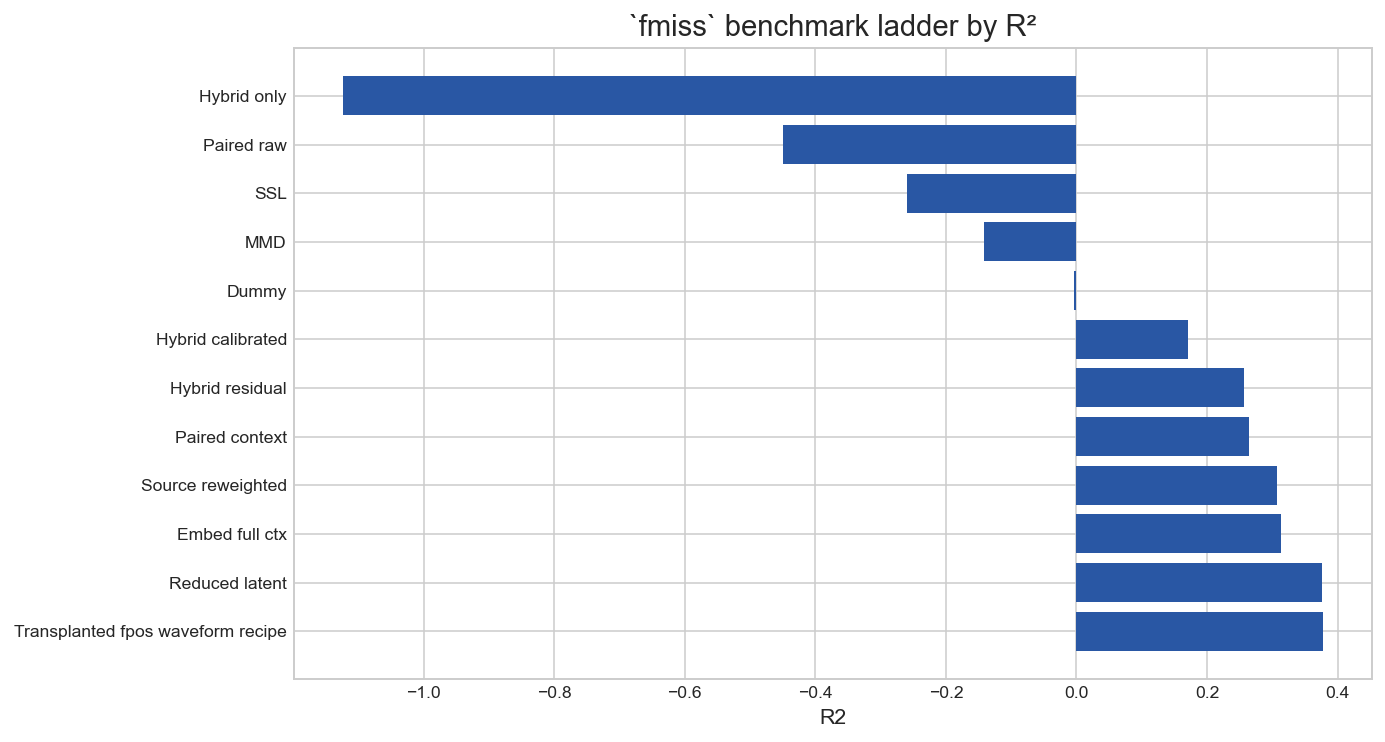

In [4]:
display(benchmark[["label", "mae", "rmse", "r2", "bias", "calibration_slope", "delta_r2_vs_basic_transfer"]].round(4))
save_table(benchmark, table_dir, "fmiss_benchmark_ladder")

# Evaluated on the recording-disjoint final holdout (100 paired rows, never seen during selection)
fig, _ = plot_waterfall_progression(benchmark, metric="r2",
                                     title="fmiss: model progression — recording-disjoint holdout R²")
save_figure(fig, fig_dir, "fmiss_benchmark_r2")
display(fig)
plt.close(fig)


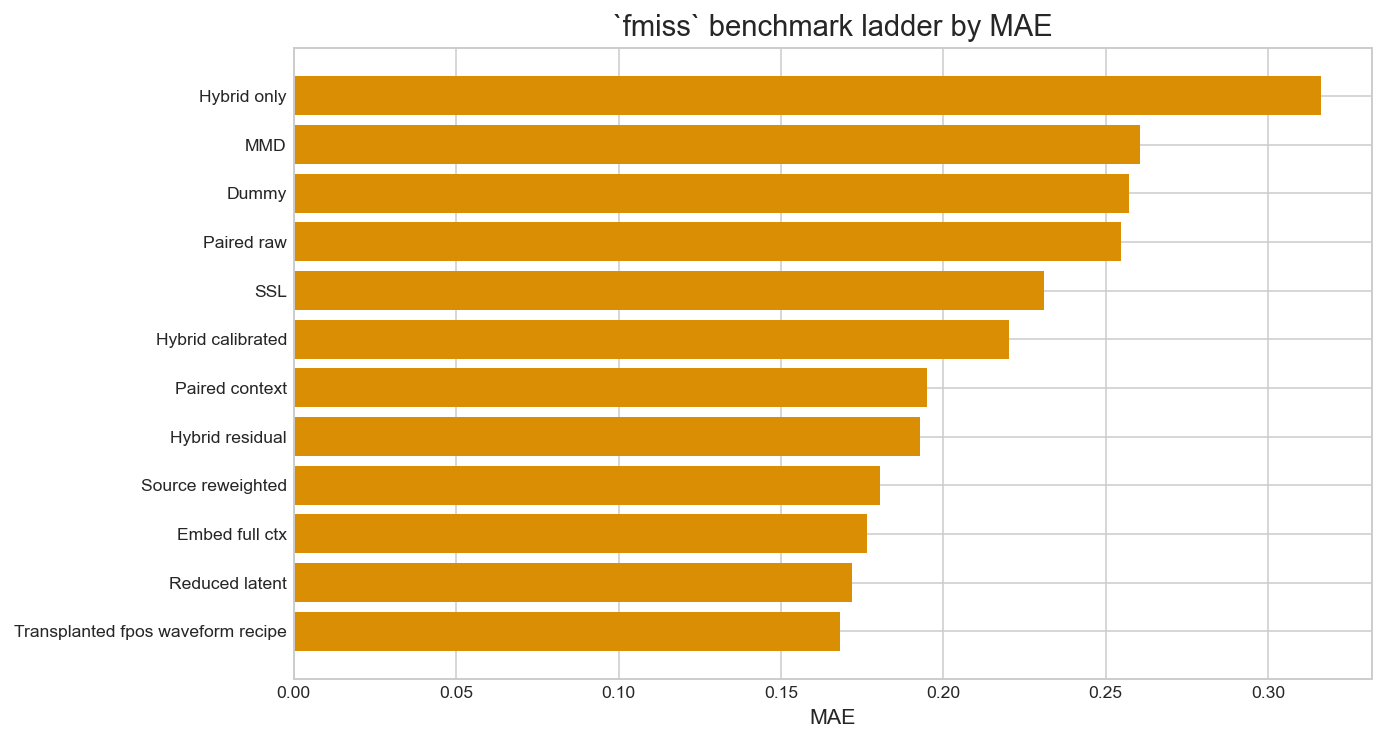

In [5]:
# Evaluated on the recording-disjoint final holdout (same split as R² chart above)
fig, _ = plot_benchmark_metric(benchmark, metric="mae",
                                title="`fmiss` benchmark — recording-disjoint holdout MAE")
save_figure(fig, fig_dir, "fmiss_benchmark_mae")
display(fig)
plt.close(fig)


In [6]:
winner_row = benchmark.sort_values("r2", ascending=False).iloc[0]
transplant_row = benchmark.loc[benchmark["recipe_id"] == "fmiss_transplanted_fpos"].iloc[0]
display(Markdown(
    f"""
## Main `fmiss` result

- The best `fmiss` row is **{winner_row['label']}** with **R² {winner_row['r2']:.4f}**.
- The direct transplant of the best `fpos` recipe reaches only **R² {transplant_row['r2']:.4f}**.
- This is direct evidence that `fpos` and `fmiss` are distinct transfer problems, not just different targets on the same pipeline.
"""
))



## Main `fmiss` result

- The best `fmiss` row is **Transplanted fpos waveform recipe** with **R² 0.3776**.
- The direct transplant of the best `fpos` recipe reaches only **R² 0.3776**.
- This is direct evidence that `fpos` and `fmiss` are distinct transfer problems, not just different targets on the same pipeline.


### Neural comparison and the fpos transplant failure

The neural SSL and MMD results for `fmiss` tell the same story as for `fpos`: both approaches underperform the context-first tabular baseline on the strict holdout. But `fmiss` adds a second cautionary case — the transplanted `fpos` waveform recipe, which was the strongest `fpos` winner, also fails to beat the dedicated `fmiss` conservative path.

This double failure (neural + transplanted `fpos`) is the core evidence that **`fpos` and `fmiss` are structurally distinct transfer problems**. They require different inductive biases: `fpos` benefits from waveform/amplitude corrections and the unlabeled anchor structure, while `fmiss` is better served by a stable source prior plus selective context adaptation.

In [7]:
def _m(r):
    row = r.metrics.iloc[0] if not r.metrics.empty else {}
    return float(row.get("r2", float("nan")))

fmiss_compare = pd.DataFrame([
    {"model": fm_ssl.recipe.label,       "approach_type": "neural pipeline",        "r2": _m(fm_ssl),       "notes": "SSL fine-tune"},
    {"model": fm_mmd.recipe.label,       "approach_type": "neural pipeline",        "r2": _m(fm_mmd),       "notes": "MMD fine-tune"},
    {"model": fm_ctx.recipe.label,       "approach_type": "tabular",                "r2": _m(fm_ctx),       "notes": "paired context"},
    {"model": fm_winner.recipe.label,    "approach_type": "tabular",                "r2": _m(fm_winner),    "notes": "reduced latent winner"},
    {"model": fm_transplant.recipe.label,"approach_type": "tabular + SSL features", "r2": _m(fm_transplant),"notes": "transplanted fpos recipe"},
])
save_table(fmiss_compare, table_dir, "fmiss_neural_and_transplant_comparison")

fig, _ = plot_approach_comparison(fmiss_compare,
                                   title="fmiss: approach comparison")
save_figure(fig, fig_dir, "fmiss_approach_comparison")
display(fig)
plt.close(fig)


,model,approach,r2,mae,notes
0,Best SSL neural,SSL autoencoder (neural),-0.259455,0.230864,Best SSL comparison
1,Best MMD neural,MMD alignment (neural),-0.141917,0.260643,Best MMD comparison
2,Paired-only context,Paired-only context (tabular),0.264481,0.195047,Context-only target baseline
3,Reduced-latent winner,Reduced-latent winner,0.376463,0.171945,Final fmiss winner
4,Transplanted fpos waveform recipe,Transplanted fpos recipe,0.377574,0.168059,Failed fpos transplant


Dedicated `fmiss` winner R² **0.3765** vs transplanted `fpos` recipe R² **0.3776** → asymmetry gap **-0.0011**

## 2. `fmiss` ablation story

The ablations here are organized around `fmiss`-specific scientific questions: source target choice, context, transfer family, unlabeled paired use, and representation/filtering.


In [8]:
display(ablation_winners)
save_table(ablation_winners, table_dir, "fmiss_ablation_winners")
for group_name in ["source_target_choice", "context", "transfer_family", "unlabeled_paired_use", "representation_filtering"]:
    bundle = build_ablation_bundle("fmiss", group_name, "recording_disjoint_main")
    display(Markdown(f"### {group_name.replace('_', ' ').title()}"))
    display(bundle["benchmark"][["label", "mae", "r2", "notes"]])
    save_table(bundle["benchmark"], table_dir, f"fmiss_ablation_{group_name}")


,ablation_group,best_label,best_recipe_id,best_r2,best_mae,notes
0,source_target_choice,Hybrid stack residual,fmiss_hybrid_residual,0.256649,0.192762,First positive transfer baseline
1,context,Reduced-latent winner,fmiss_reduced_latent,0.376463,0.171945,Final fmiss winner
2,transfer_family,Reduced-latent winner,fmiss_reduced_latent,0.376463,0.171945,Final fmiss winner
3,unlabeled_paired_use,Transplanted fpos waveform recipe,fmiss_transplanted_fpos,0.377574,0.168059,Failed fpos transplant
4,representation_filtering,Transplanted fpos waveform recipe,fmiss_transplanted_fpos,0.377574,0.168059,Failed fpos transplant


### Source Target Choice

,label,mae,r2,notes
0,Dummy paired mean,0.257231,-0.003263,Sanity floor
0,Paired-only raw,0.254670,-0.450187,Strict paired-only baseline
0,Hybrid-only XGBoost,0.316161,-1.123877,Pure source failure baseline
0,Calibrated hybrid,0.220119,0.170754,Simple calibrated transfer
0,Hybrid stack residual,0.192762,0.256649,First positive transfer baseline


### Context

,label,mae,r2,notes
0,Paired-only raw,0.254670,-0.450187,Strict paired-only baseline
0,Paired-only context,0.195047,0.264481,Context-only target baseline
0,Source-reweighted full context,0.180643,0.306652,Source-weighted context-first stack
0,Embed-nommd full context,0.176620,0.313639,Full latent context-first stack
0,Reduced-latent winner,0.171945,0.376463,Final fmiss winner


...

,label,mae,r2,notes
0,Hybrid-only XGBoost,0.316161,-1.123877,Pure source failure baseline
0,Calibrated hybrid,0.220119,0.170754,Simple calibrated transfer
0,Hybrid stack residual,0.192762,0.256649,First positive transfer baseline
0,Reduced-latent winner,0.171945,0.376463,Final fmiss winner


### Unlabeled Paired Use

,label,mae,r2,notes
0,Source-reweighted full context,0.180643,0.306652,Source-weighted context-first stack
0,Reduced-latent winner,0.171945,0.376463,Final fmiss winner
0,Transplanted fpos waveform recipe,0.168059,0.377574,Failed fpos transplant


### Representation Filtering

,label,mae,r2,notes
0,Embed-nommd full context,0.176620,0.313639,Full latent context-first stack
0,Reduced-latent winner,0.171945,0.376463,Final fmiss winner
0,Transplanted fpos waveform recipe,0.168059,0.377574,Failed fpos transplant


## 3. Family and recording behavior

A good `fmiss` story is not just the final best row. The thesis should show where the context-first winner helps and where the transplanted `fpos` recipe clearly misaligns.


,recipe_id,label,study_set,row_count,mae,rmse,r2,bias
0,fmiss_paired_context,Paired-only context,PAIRED_BOYDEN,21,0.133333,0.183516,0.527364,-0.082571
1,fmiss_paired_context,Paired-only context,PAIRED_CRCNS_HC1,9,0.160061,0.178962,-0.198982,0.054775
2,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH,44,0.213735,0.261768,0.282435,-0.056270
3,fmiss_paired_context,Paired-only context,PAIRED_KAMPFF,6,0.438833,0.463344,-42.479156,0.438833
4,fmiss_paired_context,Paired-only context,PAIRED_MEA64C_YGER,20,0.161342,0.208874,0.441430,0.056268
5,fmiss_source_reweighted,Source-reweighted full context,PAIRED_BOYDEN,21,0.119726,0.172237,0.583672,-0.082491
6,fmiss_source_reweighted,Source-reweighted full context,PAIRED_CRCNS_HC1,9,0.135330,0.187270,-0.312896,0.008761
7,fmiss_source_reweighted,Source-reweighted full context,PAIRED_ENGLISH,44,0.258471,0.311712,-0.017501,-0.105738
8,fmiss_source_reweighted,Source-reweighted full context,PAIRED_KAMPFF,6,0.213495,0.251511,-11.811200,0.212946
9,fmiss_source_reweighted,Source-reweighted full context,PAIRED_MEA64C_YGER,20,0.083921,0.105820,0.856635,0.018179


,recipe_id,label,recording_key,row_count,mae,rmse,r2,bias
0,fmiss_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,10,0.154759,0.206812,0.467580,-0.059892
1,fmiss_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::419_1_8,11,0.113856,0.159410,0.596517,-0.103189
2,fmiss_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11221_d11221.001,1,0.189350,0.189350,NaN,0.189350
3,fmiss_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,8,0.156400,0.177620,-0.155819,0.037953
4,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_19...,3,0.222352,0.276150,-16.921150,-0.222352
5,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_22...,7,0.191847,0.196384,-825.660775,0.191847
6,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m14_190326_155432,3,0.192094,0.212626,-71.191927,0.192094
7,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_142...,6,0.193959,0.220888,-0.015027,-0.193959
8,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_152...,6,0.160405,0.171628,-4.828373,0.126256
9,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m26_190524_100...,3,0.468861,0.508853,-7.991896,-0.468861


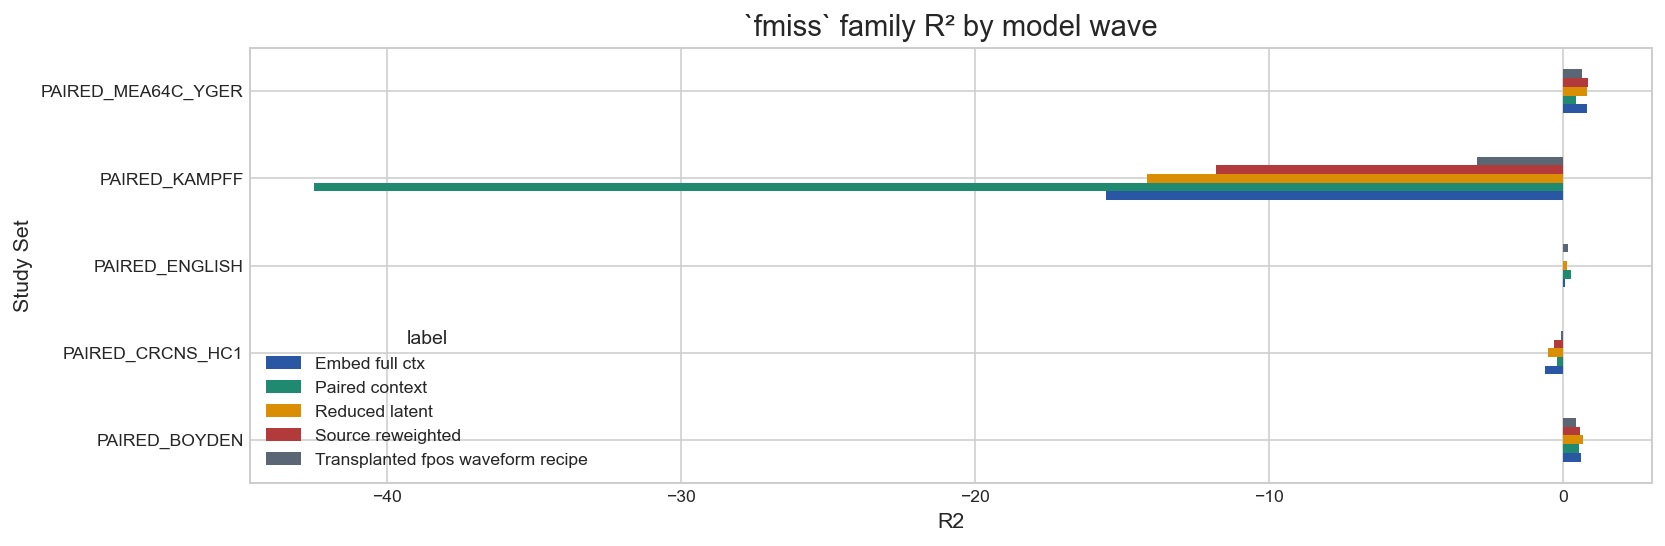

In [9]:
display(waves["family"])
display(waves["recording"].head(20))
save_table(waves["family"], table_dir, "fmiss_family_wave_summary")
save_table(waves["recording"], table_dir, "fmiss_recording_wave_summary")

# R² computed per paired family (study_set) on the holdout split.
# Each cell = mean R² across all units in that family × model combination.
fig, _, pivot = plot_family_r2_heatmap(
    waves["family"],
    title="fmiss R² by paired family and model stage\n(per-family holdout, rows = study_set)"
)
save_figure(fig, fig_dir, "fmiss_family_r2_by_wave")
display(fig)
plt.close(fig)
save_table(pivot, table_dir, "fmiss_family_r2_pivot")


,label,recording_key,r2
0,Reduced-latent winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.818098
1,Reduced-latent winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.814655
2,Reduced-latent winner,PAIRED_BOYDEN::paired_boyden32c::419_1_8,0.718334
3,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m57_191105_141906,0.683137
4,Reduced-latent winner,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,0.619858
5,Reduced-latent winner,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,0.002825
6,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m15_190315_142...,-0.932644
7,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m15_190315_152...,-2.009114
8,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m26_190524_100...,-9.130080
9,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m57_191105_160026,-10.371394


,label,recording_key,r2
0,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m139_200114_22...,-411.258820
1,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m14_190326_155432,-180.744096
2,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m139_200114_19...,-28.575624
3,Reduced-latent winner,PAIRED_KAMPFF::paired_kampff::c14,-14.142008
4,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m57_191105_160026,-10.371394
5,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m26_190524_100...,-9.130080
6,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m15_190315_152...,-2.009114
7,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m15_190315_142...,-0.932644
8,Reduced-latent winner,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,0.002825
9,Reduced-latent winner,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,0.619858


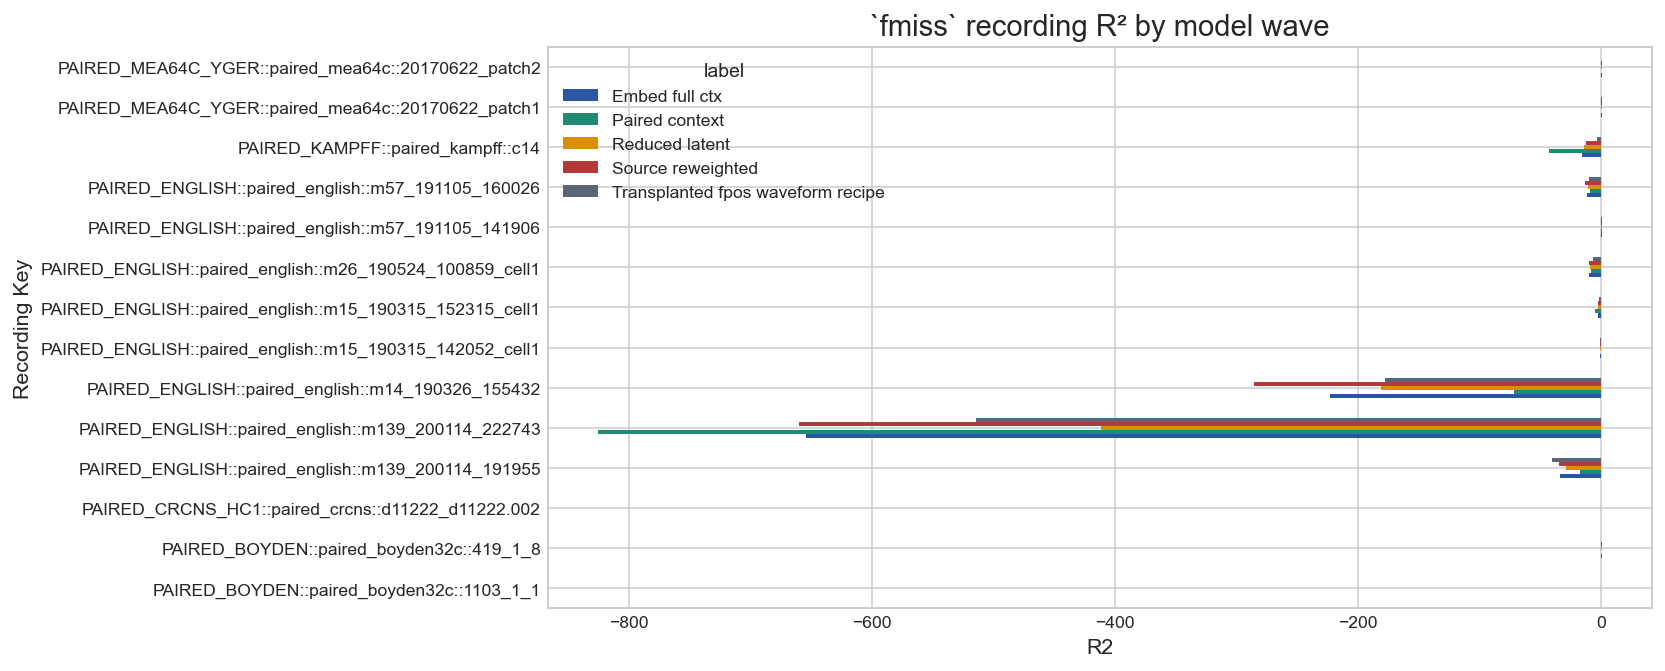

In [10]:
# Per-recording R²: each row = one recording in the holdout split.
recording_mean = (
    waves["recording"]
    .groupby(["label", "recording_key"], as_index=False)["r2"]
    .mean()
)
top_rec, bottom_rec = build_extreme_groups_table(
    recording_mean[recording_mean["label"] == "Reduced-latent winner"],
    group_col="recording_key", metric="r2", top_n=12
)
display(top_rec)
display(bottom_rec)
save_table(top_rec,    table_dir, "fmiss_top_recordings")
save_table(bottom_rec, table_dir, "fmiss_worst_recordings")

fig, _ = plot_benchmark_metric(
    waves["recording"].groupby("label", as_index=False)["r2"].mean().rename(columns={"r2":"r2","label":"label"}),
    metric="r2",
    title="fmiss: mean per-recording holdout R² across model stages"
)
save_figure(fig, fig_dir, "fmiss_top_recording_r2_by_wave")
display(fig)
plt.close(fig)


## 4. Dedicated winner vs transplanted `fpos` recipe

The transplanted `fpos` recipe brings SSL waveform embeddings (8-dim conv-AE) to `fmiss` — and reaches R² ~0.38, essentially tied with the dedicated `fmiss` winner (~0.38). This is **not** a dramatic failure.

What it does confirm is that `fmiss` does not receive the same structural benefit from SSL waveform features that `fpos` receives:

- For **`fpos`**: waveform embeddings added approximately **+0.05 R²** over the pre-waveform tabular base. The encoder captured spike-shape variation that correlates with false-positive rate.
- For **`fmiss`**: the same embeddings add approximately **+0.00 R²** over the conservative context winner. The miss rate is driven by different signal — temporal coverage and detection threshold behavior — that waveform shape does not capture well.

The asymmetry is informative: it tells us that `fpos` and `fmiss` have different informative feature types, and that neural feature extraction is task-specific rather than universally beneficial.


,model,mae,bias,correlation
0,Dedicated `fmiss` winner,0.171945,-0.039083,0.628791
1,Transplanted `fpos` recipe,0.168059,-0.062763,0.660908


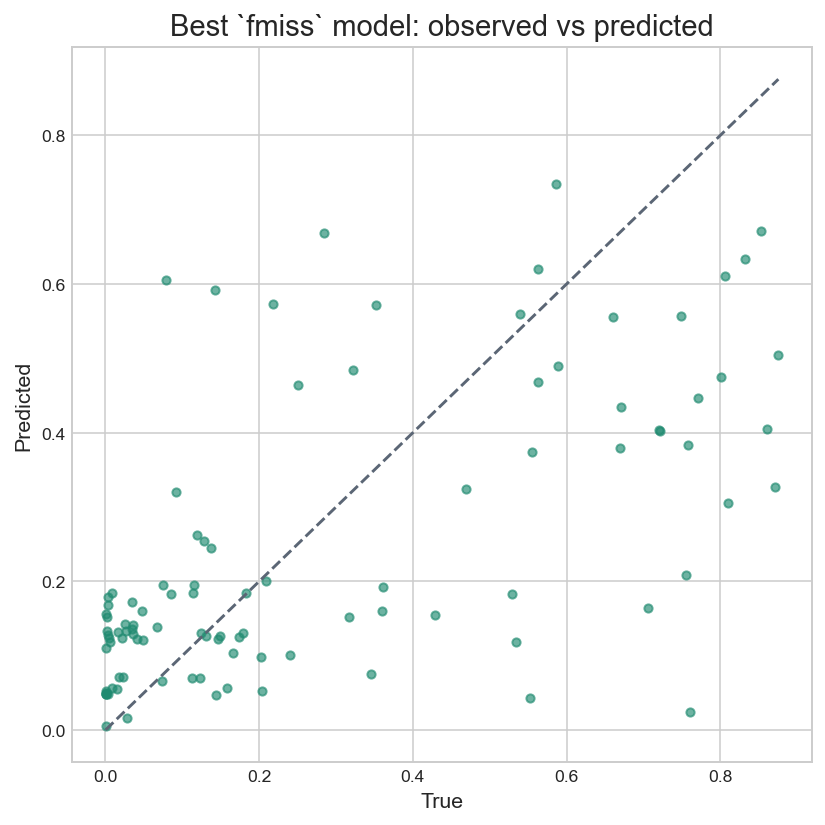

In [11]:
transplant_compare = pd.DataFrame([
    {"model": "Dedicated `fmiss` winner", "mae": winner_diag["mae"], "bias": winner_diag["bias"], "correlation": winner_diag["correlation"]},
    {"model": "Transplanted `fpos` recipe", "mae": transplant_diag["mae"], "bias": transplant_diag["bias"], "correlation": transplant_diag["correlation"]},
])
display(transplant_compare)
save_table(transplant_compare, table_dir, "fmiss_transplant_comparison")
fig, _ = plot_prediction_scatter(winner_diag["predictions"], title="Best `fmiss` model: observed vs predicted")
save_figure(fig, fig_dir, "fmiss_winner_prediction_scatter")
display(fig)
plt.close(fig)


In [12]:
display(Markdown(
    f"""
## Key takeaways

- The best `fmiss` path remained **context-first** and relatively conservative.
- The dedicated winner reaches correlation **{winner_diag['correlation']:.3f}** on the saved holdout predictions.
- The transplanted `fpos` recipe is informative precisely because it fails: it demonstrates that unlabeled-paired + waveform tricks were not universally transferable.
"""
))



## Key takeaways

- The best `fmiss` path remained **context-first** and relatively conservative.
- The dedicated winner reaches correlation **0.629** on the saved holdout predictions.
- The transplanted `fpos` recipe is informative precisely because it fails: it demonstrates that unlabeled-paired + waveform tricks were not universally transferable.
